In [1]:
import pandas as pd

df=pd.read_csv('../data/Titanic_cleaned.csv')
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Middle,AgeGroup_Senior,FareBand
0,0,3,0,22.0,1,0,7.2500,2,0,1,0,0,0,1,0,1,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,0,0,1,0,0,0,0,1,0,0,4
2,1,3,1,26.0,0,0,7.9250,1,1,0,0,0,0,1,0,1,0,0,2


In [4]:
X=df.drop(['Survived'],axis=1)
y=df['Survived']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [17]:
preds_lr = lr.predict(X_val)

In [18]:
preds_lr_prob = preds_lr.clip(0,1)

In [19]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_val, preds_lr_prob)

np.float64(0.8848133848133847)

In [20]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
preds_log = log_reg.predict_proba(X_val)[:, 1]
roc_auc_log = roc_auc_score(y_val, preds_log)

In [21]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
preds_dummy = dummy.predict(X_val)
roc_auc_dummy = roc_auc_score(y_val, preds_dummy)

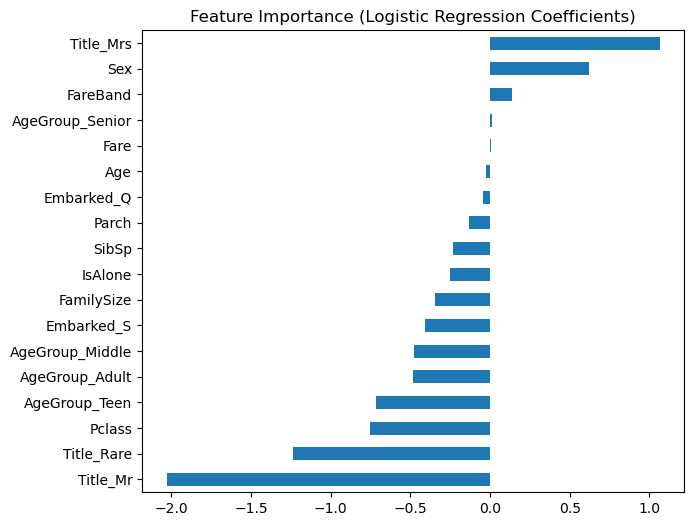

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
coef = pd.Series(log_reg.coef_[0], index=X.columns)
coef.sort_values().plot(kind='barh', figsize=(7,6))
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()